# 04 — Índice de Evolución Clínica · CES (Fase 2D)

**Clinical Evolution Score (0-100)** que combina dos componentes:

$$\text{CES}=100\,(0.5\,G_{\text{estado}} + 0.5\,E_{\text{evolución}})$$

- $E=(1+W)/2$, con $W=\text{clip}(\bar s-\mu(1-S),-1,1)$ — la **tendencia** direccional ponderada penalizada por volatilidad (hereda la matemática de `docs/clinical-evolution-score.md`).
- $G$ — el **control clínico actual** (glucosa, IMC, PA, actividad física, riesgo ML) frente a objetivos.

| CES | Interpretación |
|---|---|
| 80-100 | Excelente evolución |
| 60-79 | Estable |
| 40-59 | Riesgo moderado |
| 20-39 | Riesgo alto |
| 0-19 | Deterioro severo |

In [1]:
# --- Setup ---
import sys, json
from pathlib import Path
import pandas as pd
from IPython.display import Image, display

TCF = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(TCF / "src"))
from predia_temporal import config
DS, MET, FIG, DASH = TCF/"datasets", TCF/"metrics", TCF/"figures", TCF/"dashboards"
def show(p, w=None): display(Image(filename=str(p), width=w))
def load(j): return json.load(open(j))
pd.set_option("display.max_columns", 50); pd.set_option("display.width", 160)
print("Entorno listo:", TCF)


Entorno listo: /home/wowo/Descargas/predia/ml-research/temporal_clinical_framework


In [2]:
ces = pd.read_csv(MET/'ces.csv'); meta = pd.read_csv(DS/'cohort_meta.csv')
print('Distribución de bandas:'); print(ces.band.value_counts())
ces.merge(meta[['patient_id','archetype']],on='patient_id')\
   .groupby('archetype')['ces'].agg(['mean','std','count']).round(1).reindex(config.ARCHETYPES)

Distribución de bandas:
band
Estable                121
Deterioro severo       108
Riesgo alto             93
Riesgo moderado         51
Excelente evolución     27
Name: count, dtype: int64


,mean,std,count
archetype,,,
Mejora rápida,76.2,8.0,74
Estable,60.4,9.4,116
Deterioro lento,15.0,5.9,91
Alto riesgo persistente,19.6,4.7,63
Oscilante,34.3,12.6,56


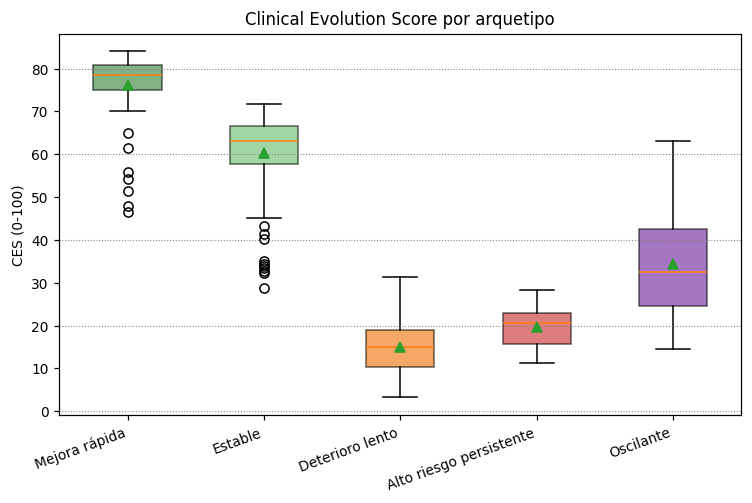

In [3]:
show(FIG/'ces'/'ces_by_archetype.png')

## CES en el tiempo
Usando una ventana móvil de 120 días, el CES evoluciona y permite ver *cuándo* mejora o se deteriora un paciente.

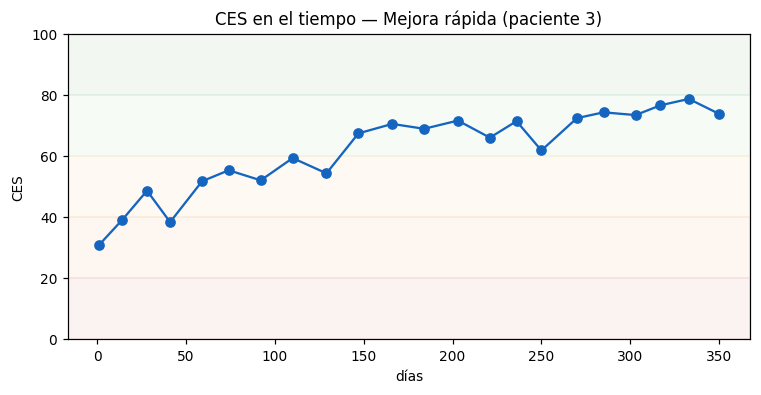

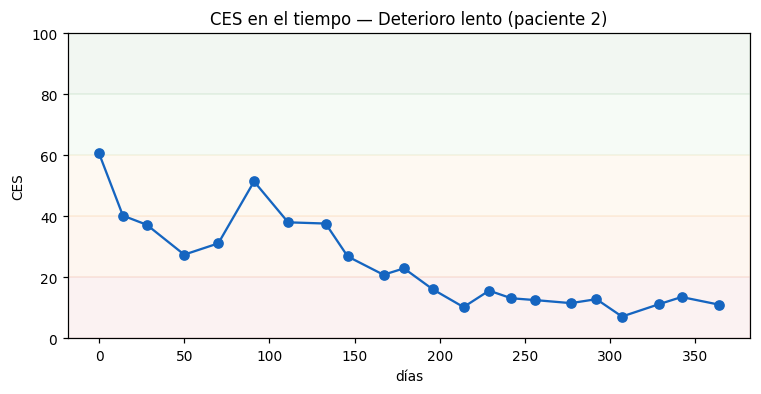

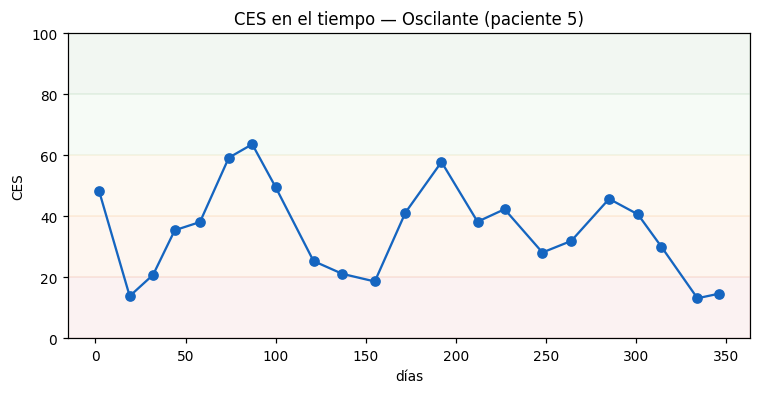

In [4]:
for a in ['Mejora_rápida','Deterioro_lento','Oscilante']:
    p = FIG/'ces'/f'ces_timeline_{a}.png'
    if p.exists(): show(p)

### Conclusión 2D
El CES ordena correctamente los arquetipos (mejora→alto, deterioro→bajo) y es **explicable** por sus componentes E (tendencia) y G (estado).